In [3]:
import pandas as pd
import os

# 1. 현재 주피터 노트북 파일이 있는 'notebook' 폴더 주소를 자동으로 가져옵니다.
notebook_dir = os.getcwd()

# 2. 'notebook' 폴더에서 한 단계 위로 나간 뒤 'outputs' 폴더 안의 합본 파일 경로를 완벽하게 계산합니다.
merged_data_path = os.path.abspath(os.path.join(notebook_dir, '..', 'outputs', '서울시_상권분석_점포_3개년_합본.csv'))

# 3. 합본 데이터를 새로 불러와 'merged_df'라는 상자에 담아줍니다.
merged_df = pd.read_csv(merged_data_path)

print(f"✅ 'outputs' 폴더에서 합본 데이터 로드 완료! 데이터 개수: {len(merged_df)}개")

✅ 'outputs' 폴더에서 합본 데이터 로드 완료! 데이터 개수: 919405개


In [4]:
# 전체적인 데이터 정보(행 개수, 컬럼별 데이터 타입, 결측치 수) 확인
merged_df.info()

# 비어있는 값(결측치)이 컬럼별로 몇 개나 있는지 확인
print("\n[컬럼별 결측치 개수]")
print(merged_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 919405 entries, 0 to 919404
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   기준_년분기_코드    919405 non-null  int64
 1   상권_구분_코드     919405 non-null  str  
 2   상권_구분_코드_명   919405 non-null  str  
 3   상권_코드        919405 non-null  int64
 4   상권_코드_명      919405 non-null  str  
 5   서비스_업종_코드    919405 non-null  str  
 6   서비스_업종_코드_명  919405 non-null  str  
 7   점포_수         919405 non-null  int64
 8   유사_업종_점포_수   919405 non-null  int64
 9   개업_율         919405 non-null  int64
 10  개업_점포_수      919405 non-null  int64
 11  폐업_률         919405 non-null  int64
 12  폐업_점포_수      919405 non-null  int64
 13  프랜차이즈_점포_수   919405 non-null  int64
dtypes: int64(9), str(5)
memory usage: 98.2 MB

[컬럼별 결측치 개수]
기준_년분기_코드      0
상권_구분_코드       0
상권_구분_코드_명     0
상권_코드          0
상권_코드_명        0
서비스_업종_코드      0
서비스_업종_코드_명    0
점포_수           0
유사_업종_점포_수     0
개업_율           0
개업_점포_수      

In [5]:
import os

# 현재 주피터 노트북이 바라보고 있는 폴더 위치를 가져옵니다.
current_folder = os.getcwd()

print("📍 현재 주피터 노트북의 폴더 위치:")
print(current_folder)

📍 현재 주피터 노트북의 폴더 위치:
c:\Users\user\OneDrive - 대한상공회의소\github_desktop\golmok-sesac_project\notebook


In [6]:
# 1. 20231 같은 기존 코드에서 앞 4자리는 '기준_년도', 마지막 1자리는 '기준_분기'로 추출합니다.
merged_df['기준_년도'] = merged_df['기준_년분기_코드'].astype(str).str[:4].astype(int)
merged_df['기준_분기'] = merged_df['기준_년분기_코드'].astype(str).str[4:].astype(int)

# 2. 역할이 겹치고 보기 복잡한 기존의 5자리 '기준_년분기_코드'는 과감하게 삭제합니다.
merged_df = merged_df.drop(columns=['기준_년분기_코드'])

# 3. 잘 분리되었는지 표의 맨 오른쪽(또는 전체 구조)을 상위 5줄만 출력해 확인합니다.
display(merged_df.head())

,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,점포_수,유사_업종_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수,기준_년도,기준_분기
0,A,골목상권,3110001,이북5도청사,CS100001,한식음식점,10,11,9,1,0,0,1,2023,1
1,A,골목상권,3110001,이북5도청사,CS100003,일식음식점,1,1,0,0,0,0,0,2023,1
2,A,골목상권,3110001,이북5도청사,CS100008,분식전문점,3,3,0,0,0,0,0,2023,1
3,A,골목상권,3110001,이북5도청사,CS100009,호프-간이주점,2,3,0,0,0,0,1,2023,1
4,A,골목상권,3110001,이북5도청사,CS100010,커피-음료,1,1,0,0,0,0,0,2023,1


In [7]:
# 1. '기준_년도'와 '기준_분기'를 맨 앞으로 당기고, 나머지 컬럼들을 순서대로 이어 붙입니다.
new_columns = ['기준_년도', '기준_분기'] + [col for col in merged_df.columns if col not in ['기준_년도', '기준_분기']]
merged_df = merged_df[new_columns]

# 2. 정렬된 표 확인
display(merged_df.head(3))

,기준_년도,기준_분기,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,점포_수,유사_업종_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수
0,2023,1,A,골목상권,3110001,이북5도청사,CS100001,한식음식점,10,11,9,1,0,0,1
1,2023,1,A,골목상권,3110001,이북5도청사,CS100003,일식음식점,1,1,0,0,0,0,0
2,2023,1,A,골목상권,3110001,이북5도청사,CS100008,분식전문점,3,3,0,0,0,0,0


In [8]:
# 1. 저장할 위치를 프로젝트 내 'outputs' 폴더 안으로 지정합니다.
save_processed_path = os.path.abspath(os.path.join(notebook_dir, '..', 'outputs', '서울시_상권분석_점포_전처리_행정동포함.csv'))

# 2. 인코딩을 적용하여 outputs 폴더에 csv 파일로 저장(생성)합니다.
merged_df.to_csv(save_processed_path, index=False, encoding='utf-8-sig')

print("🎉 전처리된 데이터 파일이 'outputs' 폴더 안에 성공적으로 저장되었습니다!")

🎉 전처리된 데이터 파일이 'outputs' 폴더 안에 성공적으로 저장되었습니다!


In [9]:
import os

# 현재 주피터 노트북이 바라보고 있는 폴더 위치를 가져옵니다.
current_folder = os.getcwd()

print("📍 현재 주피터 노트북의 폴더 위치:")
print(current_folder)

📍 현재 주피터 노트북의 폴더 위치:
c:\Users\user\OneDrive - 대한상공회의소\github_desktop\golmok-sesac_project\notebook


In [18]:
import pandas as pd
import os

# 1. 절대 경로 설정
RAW_DATA_DIR = r"C:\Users\user\OneDrive - 대한상공회의소\github_desktop\golmok-sesac_project\data\raw"
OUTPUTS_DIR  = r"C:\Users\user\OneDrive - 대한상공회의소\github_desktop\golmok-sesac_project\outputs"

processed_file_path = os.path.join(OUTPUTS_DIR, "서울시_상권분석_점포_전처리_분기컬럼.csv")
mapping_file_path   = os.path.join(RAW_DATA_DIR, "서울시 상권분석서비스(영역-상권)(in).csv")

# 탐색할 한글 인코딩 후보들
candidates = ['utf-8-sig', 'utf-8', 'cp949', 'euc-kr']

# [파일 1 로드] 전처리 분기컬럼 파일
merged_df = None
for enc in candidates:
    try:
        merged_df = pd.read_csv(processed_file_path, encoding=enc)
        print(f"✅ [성공] 전처리 분기컬럼 파일이 '{enc}' 인코딩으로 열렸습니다.")
        break
    except UnicodeDecodeError:
        continue

# [파일 2 로드] 영역-상권 마스터 파일
area_df = None
for enc in candidates:
    try:
        area_df = pd.read_csv(mapping_file_path, encoding=enc)
        print(f"✅ [성공] 영역-상권 마스터 파일이 '{enc}' 인코딩으로 열렸습니다.")
        break
    except UnicodeDecodeError:
        continue

# 둘 다 성공했는지 체크
if merged_df is not None and area_df is not None:
    print("\n🎉 두 파일 모두 에러 없이 안착했습니다! 다음 스텝으로 진행하세요.")
else:
    print("\n❌ 에러: 특정 파일의 인코딩을 찾지 못했습니다. 파일명을 다시 확인해 주세요.")

✅ [성공] 전처리 분기컬럼 파일이 'utf-8-sig' 인코딩으로 열렸습니다.
✅ [성공] 영역-상권 마스터 파일이 'utf-8-sig' 인코딩으로 열렸습니다.

🎉 두 파일 모두 에러 없이 안착했습니다! 다음 스텝으로 진행하세요.


In [19]:
# 1. 마스터 파일(area_df)에서 행정구역 매핑에 필요한 컬럼만 추출 및 중복 제거
required_cols = ['상권_코드', '자치구_코드', '자치구_코드_명', '행정동_코드', '행정동_코드_명']
area_df_sub = area_df[required_cols].drop_duplicates(subset=['상권_코드'])

# 2. '상권_코드'를 기준으로 두 데이터 병합 (Left Join)
merged_df = pd.merge(merged_df, area_df_sub, on='상권_코드', how='left')

# 3. 자치구_코드_명이 '마포구'인 데이터만 필터링
mapo_df = merged_df[merged_df['자치구_코드_명'] == '마포구'].reset_index(drop=True)

# 4. 보기 좋게 연도, 분기, 자치구명, 행정동명을 맨 앞으로 정렬
front_cols = ['기준_년도', '기준_분기', '자치구_코드_명', '행정동_코드_명', '상권_코드_명']
front_cols = [col for col in front_cols if col in mapo_df.columns]
other_cols = [col for col in mapo_df.columns if col not in front_cols]
mapo_df = mapo_df[front_cols + other_cols]

print(f"✅ 마포구 데이터 필터링 완료! (총 {len(mapo_df):,}행)")
display(mapo_df.head(3))

✅ 마포구 데이터 필터링 완료! (총 45,180행)


,기준_년도,기준_분기,자치구_코드_명,행정동_코드_명,상권_코드_명,상권_구분_코드,상권_구분_코드_명,상권_코드,서비스_업종_코드,서비스_업종_코드_명,점포_수,유사_업종_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수,자치구_코드,행정동_코드
0,2023,1,마포구,망원1동,망원나들목체육관,A,골목상권,3110540,CS100001,한식음식점,8,9,0,0,0,0,1,11440,11440690
1,2023,1,마포구,망원1동,망원나들목체육관,A,골목상권,3110540,CS100003,일식음식점,2,2,0,0,0,0,0,11440,11440690
2,2023,1,마포구,망원1동,망원나들목체육관,A,골목상권,3110540,CS100006,패스트푸드점,1,1,0,0,0,0,0,11440,11440690


In [20]:
# 마포구 수치형 데이터 요약 통계 확인 (소수점 둘째 자리까지 깔끔하게)
display(mapo_df.describe().round(2))

,기준_년도,기준_분기,상권_코드,점포_수,유사_업종_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수,자치구_코드,행정동_코드
count,45180.00,45180.00,45180.00,45180.00,45180.00,45180.00,45180.00,45180.00,45180.00,45180.00,45180.0,45180.00
mean,2024.00,2.50,3115450.66,6.31,6.88,2.65,0.22,2.45,0.21,0.57,11440.0,11440655.34
std,0.82,1.12,7273.49,15.99,17.37,11.33,1.05,11.76,0.91,2.31,0.0,54.47
min,2023.00,1.00,3110540.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11440.0,11440555.00
25%,2023.00,1.00,3110557.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,11440.0,11440600.00
50%,2024.00,3.00,3110576.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,11440.0,11440660.00
75%,2025.00,3.25,3120103.00,5.00,6.00,0.00,0.00,0.00,0.00,0.00,11440.0,11440700.00
max,2025.00,4.00,3130198.00,334.00,365.00,200.00,109.00,300.00,29.00,51.00,11440.0,11440740.00


In [21]:
# [1] 저장할 파일의 최종 경로 생성
output_file_path = os.path.join(OUTPUTS_DIR, "서울시_상권분석_점포_전처리_마포구_필터링.csv")

# [2] 데이터프레임을 CSV 파일로 저장
# 인덱스(행 번호)는 제외하고, 엑셀에서도 한글이 절대 깨지지 않도록 utf-8-sig를 적용합니다.
mapo_df.to_csv(output_file_path, index=False, encoding='utf-8-sig')

print(f"💾 파일 저장 완료!")
print(f"경로: {output_file_path}")
print(f"저장된 데이터 규모: {len(mapo_df):,}행 x {len(mapo_df.columns)}열")

💾 파일 저장 완료!
경로: C:\Users\user\OneDrive - 대한상공회의소\github_desktop\golmok-sesac_project\outputs\서울시_상권분석_점포_전처리_마포구_필터링.csv
저장된 데이터 규모: 45,180행 x 19열


In [22]:
# 1. 상관분석에 사용할 수치형 핵심 컬럼들만 선택
analysis_cols = [
    '점포_수', '유사_업종_점포_수', '개업_율', 
    '개업_점포_수', '폐업_율', '폐업_점포_수', '프랜차이즈_점포_수'
]

# 2. 피어슨 상관계수 행렬 계산 (소수점 둘째 자리까지 깔끔하게 반올림)
correlation_matrix = mapo_df[analysis_cols].corr().round(2)

print("📊 [3단계] 마포구 상권 변수 간 상관계수 행렬 결과:")
display(correlation_matrix)

KeyError: "['폐업_율'] not in index"

In [23]:
# 1. 먼저 컬럼명 좌우에 있을지 모르는 미세한 공백(띄어쓰기)을 싹 청소합니다.
# (이 작업으로 '폐업 률' 내부에 있는 공백이나 양 끝 공백이 '폐업_률' 형태로 매칭될 수 있게 정돈됩니다)
mapo_df.columns = mapo_df.columns.str.replace(' ', '_').str.strip()

# 2. '개업_율'이 있다면 '개업_률'로 공식 변경합니다.
rename_dict = {}
if '개업_율' in mapo_df.columns:
    rename_dict['개업_율'] = '개업_률'
if '폐업_율' in mapo_df.columns:
    rename_dict['폐업_율'] = '폐업_률'

mapo_df = mapo_df.rename(columns=rename_dict)

print("✅ 컬럼명 정제 완료!")
print("현재 수치형 컬럼 목록:", [col for col in mapo_df.columns if '점포' in col or '률' in col])

✅ 컬럼명 정제 완료!
현재 수치형 컬럼 목록: ['점포_수', '유사_업종_점포_수', '개업_률', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수']


In [24]:
# [1] 동일한 파일 경로 지정 (덮어쓰기)
output_file_path = os.path.join(OUTPUTS_DIR, "서울시_상권분석_점포_전처리_마포구_필터링.csv")

# [2] 올바른 맞춤법 헤더가 반영된 데이터프레임을 다시 CSV로 저장
# 엑셀 깨짐을 방지하는 utf-8-sig를 적용합니다.
mapo_df.to_csv(output_file_path, index=False, encoding='utf-8-sig')

print(f"💾 [완료] 올바른 맞춤법 헤더('개업_률', '폐업_률')가 반영된 파일이 안전하게 저장되었습니다!")
print(f"경로: {output_file_path}")

💾 [완료] 올바른 맞춤법 헤더('개업_률', '폐업_률')가 반영된 파일이 안전하게 저장되었습니다!
경로: C:\Users\user\OneDrive - 대한상공회의소\github_desktop\golmok-sesac_project\outputs\서울시_상권분석_점포_전처리_마포구_필터링.csv


In [25]:
# 올바르게 수정된 컬럼명 반영
analysis_cols = [
    '점포_수', '유사_업종_점포_수', '개업_률', 
    '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수'
]

# 안전장치: 실제로 존재하는 컬럼들만 추려서 상관분석 진행
available_cols = [col for col in analysis_cols if col in mapo_df.columns]
correlation_matrix = mapo_df[available_cols].corr().round(2)

print("📊 [3단계] 마포구 상권 변수 간 상관계수 행렬 결과:")
display(correlation_matrix)

📊 [3단계] 마포구 상권 변수 간 상관계수 행렬 결과:


,점포_수,유사_업종_점포_수,개업_률,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수
점포_수,1.00,0.99,0.02,0.65,0.02,0.76,0.55
유사_업종_점포_수,0.99,1.00,0.02,0.66,0.02,0.77,0.64
개업_률,0.02,0.02,1.00,0.27,0.12,0.05,0.03
개업_점포_수,0.65,0.66,0.27,1.00,0.04,0.57,0.48
폐업_률,0.02,0.02,0.12,0.04,1.00,0.28,0.03
폐업_점포_수,0.76,0.77,0.05,0.57,0.28,1.00,0.54
프랜차이즈_점포_수,0.55,0.64,0.03,0.48,0.03,0.54,1.00


In [27]:
!pip install seaborn matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\user\AppData\Local\Temp\ipykernel_28160\3343063657.py:24: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\user\OneDrive - 대한상공회의소\github_desktop\golmok-sesac_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


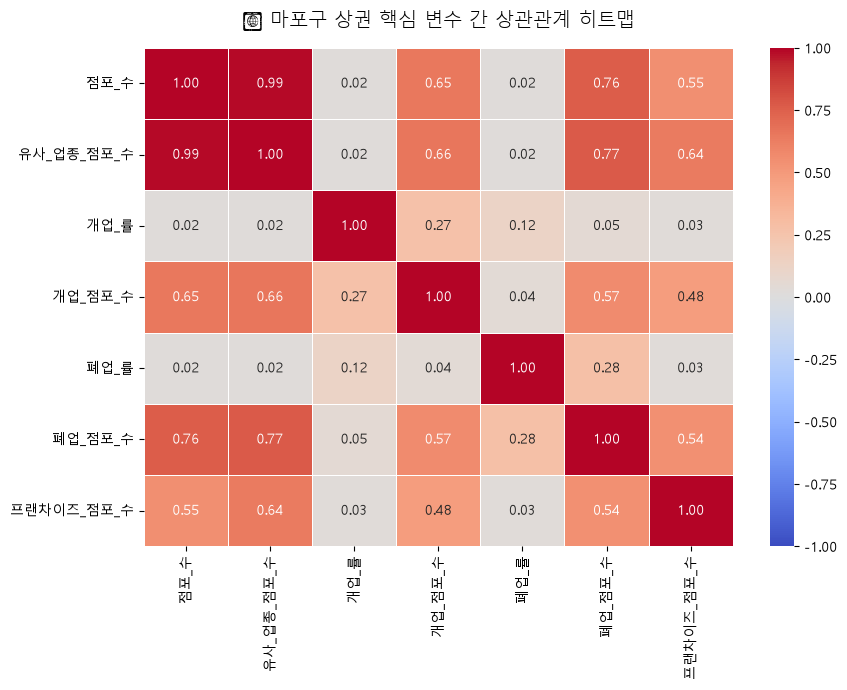

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 깨짐 방지를 위한 맑은 고딕(Malgun Gothic) 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 2. 히트맵 전용 스타일 및 크기 설정
plt.figure(figsize=(9, 7))

# 3. Seaborn 히트맵 그리기
# (상관계수 숫자를 표시하고, 눈이 편안한 coolwarm 컬러맵을 사용합니다)
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)

plt.title('📊 마포구 상권 핵심 변수 간 상관관계 히트맵', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [29]:
# [1] 올려주신 이미지(image_727427.png)의 공식 영어 축약 헤더명 그대로 매핑 정의
# + 이전 단계에서 결합한 구/동 명칭 및 일부 누락된 컬럼도 규칙에 맞게 추가했습니다.
official_rename_dict = {
    '기준_년도': 'stdr_yy_cd',          # 기준 년도
    '기준_분기': 'stdr_qu_cd',          # 기준 분기
    '상권_구분_코드': 'trdar_se_cd',      # 상권 구분 코드
    '상권_구분_코드_명': 'trdar_se_cd_nm', # 상권 구분 코드명
    '상권_코드': 'trdar_cd',            # 상권 코드
    '상권_코드_명': 'trdar_cd_nm',         # 상권 코드명
    '자치구_코드': 'signgu_cd',          # 자치구 코드 (표준 표준형 확장)
    '자치구_코드_명': 'signgu_cd_nm',     # 자치구 코드명
    '행정동_코드': 'adstrd_cd',          # 행정동 코드
    '행정동_코드_명': 'adstrd_cd_nm',     # 행정동 코드명
    '서비스_업종_코드': 'svc_induty_cd',    # 서비스 업종 코드
    '서비스_업종_코드_명': 'svc_induty_cd_nm', # 서비스 업종 코드명
    '점포_수': 'stor_co',               # 점포 수
    '유사_업종_점포_수': 'similr_induty_stor_co', # 유사 업종 점포 수
    '개업_률': 'opbiz_rt',             # 개업 률
    '개업_점포_수': 'opbiz_stor_co',      # 개업 점포 수
    '폐업_률': 'clsbiz_rt',            # 폐업 률
    '폐업_점포_수': 'clsbiz_stor_co',     # 폐업 점포 수
    '프랜차이즈_점포_수': 'frc_stor_co'     # 프랜차이즈 점포 수
}

# [2] 컬럼명 일괄 변환
mapo_df_official = mapo_df.rename(columns=official_rename_dict)

# [3] 분석 편의성을 위한 직관적인 컬럼 순서 정렬 (코드 데이터와 가독성용 String 데이터 조화)
# 데이터프레임에 실제 존재하는 컬럼들만 안전하게 추려냅니다.
desired_order = [
    'stdr_yy_cd', 'stdr_qu_cd', 
    'signgu_cd', 'signgu_cd_nm', 'adstrd_cd', 'adstrd_cd_nm', 
    'trdar_cd', 'trdar_cd_nm',
    'stor_co', 'similr_induty_stor_co', 
    'opbiz_rt', 'opbiz_stor_co', 'clsbiz_rt', 'clsbiz_stor_co', 'frc_stor_co'
]
final_cols = [col for col in desired_order if col in mapo_df_official.columns]
mapo_df_final = mapo_df_official[final_cols]


# [4] 한글 깨짐 없는 원화 인코딩(utf-8-sig)을 적용하여 outputs에 최종 저장
final_output_path = os.path.join(OUTPUTS_DIR, "서울시_상권분석_점포_전처리_마포구_최종_ENG.csv")
mapo_df_final.to_csv(final_output_path, index=False, encoding='utf-8-sig')


print("🎉 [미션 최종 완료] 공식 표준 축약 헤더명이 완벽하게 반영되었습니다!")
print(f"💾 최종본 저장 경로: {final_output_path}")
print("\n변환된 공식 영어 축약 헤더 기반 데이터 샘플:")
display(mapo_df_final.head(2))

🎉 [미션 최종 완료] 공식 표준 축약 헤더명이 완벽하게 반영되었습니다!
💾 최종본 저장 경로: C:\Users\user\OneDrive - 대한상공회의소\github_desktop\golmok-sesac_project\outputs\서울시_상권분석_점포_전처리_마포구_최종_ENG.csv

변환된 공식 영어 축약 헤더 기반 데이터 샘플:


,stdr_yy_cd,stdr_qu_cd,signgu_cd,signgu_cd_nm,adstrd_cd,adstrd_cd_nm,trdar_cd,trdar_cd_nm,stor_co,similr_induty_stor_co,opbiz_rt,opbiz_stor_co,clsbiz_rt,clsbiz_stor_co,frc_stor_co
0,2023,1,11440,마포구,11440690,망원1동,3110540,망원나들목체육관,8,9,0,0,0,0,1
1,2023,1,11440,마포구,11440690,망원1동,3110540,망원나들목체육관,2,2,0,0,0,0,0
